# Importing Data

In [16]:
import torch
from torchvision import datasets, transforms
from datasets import load_dataset

def importTestVariant(path):
    return datasets.ImageFolder(root=path, transform=test_variant_transforms)

# Main dataset
food = load_dataset("ethz/food101")

# Training set
train = food['train']
test = food['validation'] # DO NOT USE (use test_clean instead)

test_variant_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

clean_path = './test_splits/clean'
blur_little_path = './test_splits/blur_little'
blur_medium_path = './test_splits/blur_medium'
downsampled_path = './test_splits/downsampled'
masked_path = './test_splits/masked'
noise_rotation_path = './test_splits/noise_rotation'

# Test set variants
test_clean = importTestVariant(clean_path)
test_blur_little = importTestVariant(blur_little_path)
test_blur_medium = importTestVariant(blur_medium_path)
test_downsampled = importTestVariant(downsampled_path)
test_masked = importTestVariant(masked_path)
test_noise_rotation = importTestVariant(noise_rotation_path)

print("DATASET SIZES")
print()
print(f"Training: {len(train)}")
print(f"Test (Clean): {len(test_clean)}")
print()
print(f"Test (Blur Little): {len(test_blur_little)}")
print(f"Test (Blur Medium): {len(test_blur_medium)}")
print(f"Test (Downsampled): {len(test_downsampled)}")
print(f"Test (Masked): {len(test_masked)}")
print(f"Test (Noise Rotation): {len(test_noise_rotation)}")

DATASET SIZES

Training: 75750
Test (Clean): 25250

Test (Blur Little): 25250
Test (Blur Medium): 25250
Test (Downsampled): 25250
Test (Masked): 25250
Test (Noise Rotation): 25250


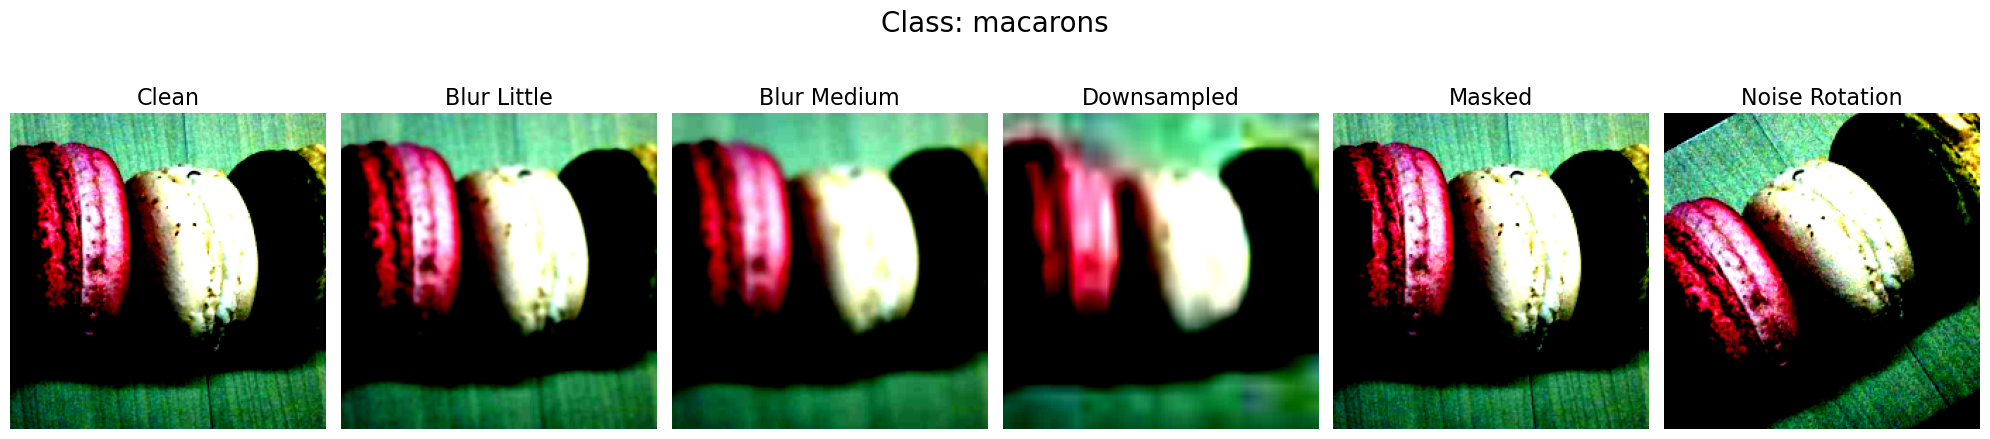

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import random

test_sets = [
    ("Clean", test_clean),
    ("Blur Little", test_blur_little),
    ("Blur Medium", test_blur_medium),
    ("Downsampled", test_downsampled),
    ("Masked", test_masked),
    ("Noise Rotation", test_noise_rotation)
]

random_idx = random.randint(0, len(test_blur_little) - 1)
_, label_idx = test_blur_little[random_idx]

fig, axes = plt.subplots(1, len(test_sets), figsize=(20, 5))

for i, (name, dset) in enumerate(test_sets):
    img_tensor, _ = dset[random_idx]
    img = img_tensor.permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    axes[i].imshow(img)
    axes[i].set_title(name, fontsize=16)
    axes[i].axis('off')

fig.suptitle(f"Class: {test_blur_little.classes[label_idx]}", fontsize=20)
plt.tight_layout()
plt.show()

In [22]:
food_classes = test_clean.classes

print(f"Number of Classes: {len(food_classes)}")
print()
print('\n'.join(food_classes))

Number of Classes: 101

apple_pie
baby_back_ribs
baklava
beef_carpaccio
beef_tartare
beet_salad
beignets
bibimbap
bread_pudding
breakfast_burrito
bruschetta
caesar_salad
cannoli
caprese_salad
carrot_cake
ceviche
cheese_plate
cheesecake
chicken_curry
chicken_quesadilla
chicken_wings
chocolate_cake
chocolate_mousse
churros
clam_chowder
club_sandwich
crab_cakes
creme_brulee
croque_madame
cup_cakes
deviled_eggs
donuts
dumplings
edamame
eggs_benedict
escargots
falafel
filet_mignon
fish_and_chips
foie_gras
french_fries
french_onion_soup
french_toast
fried_calamari
fried_rice
frozen_yogurt
garlic_bread
gnocchi
greek_salad
grilled_cheese_sandwich
grilled_salmon
guacamole
gyoza
hamburger
hot_and_sour_soup
hot_dog
huevos_rancheros
hummus
ice_cream
lasagna
lobster_bisque
lobster_roll_sandwich
macaroni_and_cheese
macarons
miso_soup
mussels
nachos
omelette
onion_rings
oysters
pad_thai
paella
pancakes
panna_cotta
peking_duck
pho
pizza
pork_chop
poutine
prime_rib
pulled_pork_sandwich
ramen
ravioli
re

# Backbone

In [23]:
import torch.nn as nn
from torchvision import models

# Number of classes of food in the dataset
num_classes = 101

# ResNet18
resnet = models.resnet18(weights='IMAGENET1K_V1')
# Adjust the output layer for the specific number of classes
num_ftrs_res = resnet.fc.in_features
resnet.fc = nn.Linear(num_ftrs_res, num_classes)

# EfficientNetV2-S
effnet = models.efficientnet_v2_s(weights='IMAGENET1K_V1')
# Adjust the output layer for the specific number of classes
num_ftrs_eff = effnet.classifier[1].in_features
effnet.classifier[1] = nn.Linear(num_ftrs_eff, num_classes)

# Linear Probing

In [24]:
import copy

def freezeAllLayers(model):
    for param in model.parameters():
        param.requires_grad = False

# ResNet18 Baseline
resnet_baseline = copy.deepcopy(resnet)
freezeAllLayers(resnet_baseline)
# Unfreeze last layer
resnet_baseline.fc.weight.requires_grad = True
resnet_baseline.fc.bias.requires_grad = True

# EfficientNetV2-S Baseline
effnet_baseline = copy.deepcopy(effnet)
freezeAllLayers(effnet_baseline)
# Unfreeze last layer
effnet_baseline.classifier[1].weight.requires_grad = True
effnet_baseline.classifier[1].bias.requires_grad = True